## 01 - Preprocessing Pipeline Verification

**Purpose:** Run the DATA_PROTOCOL 31-point verification checklist on the preprocessing pipeline.

**Checks:**
- 10 basic preprocessing checks (shapes, NaN, Inf, scaling, overlap, shuffle test, PCA)
- 21 extended DATA_PROTOCOL checks (V1-V21)

**Outputs:**
- `results/plots/pca_preprocessed_BRCA.png`
- `results/plots/pca_preprocessed_COAD.png`
- `results/qc/preprocessing_verification.json`

> *Academic research prototype. Not for clinical use.*

## 1. Setup

In [1]:
import sys, os, json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA

# Ensure CWD is project root (handles execution from notebooks/ dir)
project_root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

warnings.filterwarnings('ignore', category=UserWarning)

from src.utils import set_seeds, load_config
from src.data_loader import load_modality, load_labels, get_common_samples, MODALITY_KEYS
from src.preprocessing import (
    PerModalityImputer, PerModalityScaler,
    prepare_fold_data, concatenate_modalities,
    load_cv_folds
)

set_seeds(42)
config = load_config()

results = {}
print('Setup complete. Seed=42, config loaded.')
print(f'CWD: {os.getcwd()}')

Setup complete. Seed=42, config loaded.
CWD: e:\Projects\multi-omics-cancer-subtype-classifier


## 2. Load Raw Data

In [2]:
raw_data = {}
for cancer in ['GS-BRCA', 'GS-COAD']:
    raw_data[cancer] = {}
    for mod_key in MODALITY_KEYS:
        raw_data[cancer][mod_key] = load_modality(cancer, mod_key, config)
    raw_data[cancer]['labels'] = load_labels(cancer, config)
    raw_data[cancer]['common'] = get_common_samples(cancer, config)

In [3]:
expected_features = {'mrna': 5000, 'methy': 5000, 'cnv': 5000}

for cancer in ['GS-BRCA', 'GS-COAD']:
    print(f'\n=== {cancer} ===')
    for mod_key in MODALITY_KEYS:
        shape = raw_data[cancer][mod_key].shape
        nan_count = int(raw_data[cancer][mod_key].isna().sum().sum())
        nan_pct = nan_count / raw_data[cancer][mod_key].size * 100 if raw_data[cancer][mod_key].size > 0 else 0
        print(f'  {mod_key:6s}: {str(shape):16s}  NaN: {nan_count:>7,} ({nan_pct:.1f}%)')
    n_common = len(raw_data[cancer]['common'])
    n_labels = len(raw_data[cancer]['labels'])
    print(f'  Common samples: {n_common}')
    print(f'  Labels: {n_labels} samples, {raw_data[cancer]["labels"].nunique()} subtypes')


=== GS-BRCA ===
  mrna  : (671, 5000)       NaN:       0 (0.0%)
  mirna : (671, 366)        NaN: 111,386 (45.4%)
  methy : (671, 5000)       NaN:       0 (0.0%)
  cnv   : (671, 5000)       NaN:       0 (0.0%)
  Common samples: 671
  Labels: 671 samples, 5 subtypes

=== GS-COAD ===
  mrna  : (260, 5000)       NaN:       0 (0.0%)
  mirna : (260, 200)        NaN:       0 (0.0%)
  methy : (260, 5000)       NaN:       0 (0.0%)
  cnv   : (260, 5000)       NaN:       0 (0.0%)
  Common samples: 260
  Labels: 260 samples, 4 subtypes


## 3. CV Folds Verification

In [4]:
for cancer in ['GS-BRCA', 'GS-COAD']:
    cv_data = load_cv_folds(cancer, config)
    folds = cv_data['folds']
    print(f'\n=== {cancer}: {cv_data["n_folds"]} folds, {cv_data["n_samples"]} samples ===')
    print(f'  Class distribution: {cv_data["class_distribution"]}')

    all_val = []
    for f in folds:
        overlap = set(f['train']) & set(f['val'])
        total = len(f['train']) + len(f['val'])
        all_val.extend(f['val'])
        status = 'OK' if len(overlap) == 0 else 'LEAK!'
        print(f'  Fold {f["fold"]}: train={len(f["train"]):>4}, val={len(f["val"]):>4}, '
              f'total={total}, overlap={len(overlap)} [{status}]')

    assert len(all_val) == cv_data['n_samples'], f'Val count mismatch: {len(all_val)}'
    assert len(set(all_val)) == cv_data['n_samples'], 'Duplicate val entries!'
    print(f'  Every sample appears exactly once in val: OK')


=== GS-BRCA: 5 folds, 671 samples ===
  Class distribution: {'0': 353, '1': 42, '2': 132, '3': 31, '4': 113}
  Fold 0: train= 536, val= 135, total=671, overlap=0 [OK]
  Fold 1: train= 537, val= 134, total=671, overlap=0 [OK]
  Fold 2: train= 537, val= 134, total=671, overlap=0 [OK]
  Fold 3: train= 537, val= 134, total=671, overlap=0 [OK]
  Fold 4: train= 537, val= 134, total=671, overlap=0 [OK]
  Every sample appears exactly once in val: OK

=== GS-COAD: 5 folds, 260 samples ===
  Class distribution: {'0': 174, '1': 48, '2': 34, '3': 4}
  Fold 0: train= 208, val=  52, total=260, overlap=0 [OK]
  Fold 1: train= 208, val=  52, total=260, overlap=0 [OK]
  Fold 2: train= 208, val=  52, total=260, overlap=0 [OK]
  Fold 3: train= 208, val=  52, total=260, overlap=0 [OK]
  Fold 4: train= 208, val=  52, total=260, overlap=0 [OK]
  Every sample appears exactly once in val: OK


## 4. Process Fold 0 (Demonstration)

Full pipeline: load &rarr; split &rarr; impute (train-fit) &rarr; scale (train-fit).

In [5]:
brca_cv = load_cv_folds('GS-BRCA', config)
fold_0 = brca_cv['folds'][0]

result = prepare_fold_data('GS-BRCA', fold_0, config)

print('=== BRCA Fold 0: Preprocessed Shapes ===')
for mod_key in MODALITY_KEYS:
    tr_shape = result['X_train'][mod_key].shape
    vl_shape = result['X_val'][mod_key].shape
    print(f'  {mod_key}: train={tr_shape}, val={vl_shape}')
print(f'  y_train: {result["y_train"].shape}, y_val: {result["y_val"].shape}')

=== BRCA Fold 0: Preprocessed Shapes ===
  mrna: train=(536, 5000), val=(135, 5000)
  mirna: train=(536, 366), val=(135, 366)
  methy: train=(536, 5000), val=(135, 5000)
  cnv: train=(536, 5000), val=(135, 5000)
  y_train: (536,), y_val: (135,)


In [6]:
print('=== Train Mean/Std (should be ~0/~1) ===')
for mod_key in MODALITY_KEYS:
    vals = result['X_train'][mod_key].values
    mean = vals.mean()
    std = vals.std()
    print(f'  {mod_key}: mean={mean:+.6f}, std={std:.6f}')

print('\n=== Val Mean/Std (may differ - this is CORRECT) ===')
for mod_key in MODALITY_KEYS:
    vals = result['X_val'][mod_key].values
    mean = vals.mean()
    std = vals.std()
    print(f'  {mod_key}: mean={mean:+.6f}, std={std:.6f}')

=== Train Mean/Std (should be ~0/~1) ===
  mrna: mean=-0.000000, std=1.000000
  mirna: mean=+0.000000, std=0.739221
  methy: mean=+0.000000, std=1.000000
  cnv: mean=+0.000000, std=1.000000

=== Val Mean/Std (may differ - this is CORRECT) ===
  mrna: mean=-0.005664, std=1.023534
  mirna: mean=+0.001075, std=0.729400
  methy: mean=+0.039047, std=1.009301
  cnv: mean=-0.009380, std=0.985067


In [7]:
print('=== Post-Preprocessing NaN/Inf Check ===')
for split_name, data_dict in [('train', result['X_train']), ('val', result['X_val'])]:
    for mod_key in MODALITY_KEYS:
        nan_count = int(data_dict[mod_key].isna().sum().sum())
        inf_count = int(np.isinf(data_dict[mod_key].values).sum())
        status = 'OK' if nan_count == 0 and inf_count == 0 else 'FAIL'
        print(f'  {split_name}/{mod_key}: NaN={nan_count}, Inf={inf_count} [{status}]')

=== Post-Preprocessing NaN/Inf Check ===
  train/mrna: NaN=0, Inf=0 [OK]
  train/mirna: NaN=0, Inf=0 [OK]
  train/methy: NaN=0, Inf=0 [OK]
  train/cnv: NaN=0, Inf=0 [OK]
  val/mrna: NaN=0, Inf=0 [OK]
  val/mirna: NaN=0, Inf=0 [OK]
  val/methy: NaN=0, Inf=0 [OK]
  val/cnv: NaN=0, Inf=0 [OK]


In [8]:
X_train_concat, feature_names = concatenate_modalities(result['X_train'])
X_val_concat, _ = concatenate_modalities(result['X_val'])

print(f'Concatenated train: {X_train_concat.shape}')
print(f'Concatenated val:   {X_val_concat.shape}')
print(f'Total features: {len(feature_names)}')
print(f'First 3: {feature_names[:3]}')
print(f'Last 3:  {feature_names[-3:]}')

Concatenated train: (536, 15366)
Concatenated val:   (135, 15366)
Total features: 15366
First 3: ['mrna_C1orf210', 'mrna_GPBP1L1', 'mrna_DEF8']
Last 3:  ['cnv_MBLAC1', 'cnv_REXO2', 'cnv_ARFIP1']


## 5. PCA Visualization

2D PCA colored by cancer subtype. Looking for class separation (good) vs batch effects (bad).

In [9]:
os.makedirs('results/plots', exist_ok=True)

subtype_labels = {
    'GS-BRCA': {0: 'Basal', 1: 'Her2', 2: 'LumA', 3: 'LumB', 4: 'Normal'},
    'GS-COAD': {0: 'CIN', 1: 'CIMP', 2: 'GS', 3: 'MSI'}
}

colors_brca = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#264653']
colors_coad = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']

def plot_pca(X, y, cancer, label_map, colors, save_path):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    var = pca.explained_variance_ratio_

    fig, ax = plt.subplots(figsize=(8, 6))
    for cls_idx in sorted(np.unique(y)):
        mask = y == cls_idx
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=colors[int(cls_idx)], label=label_map.get(int(cls_idx), str(cls_idx)),
            alpha=0.6, s=30, edgecolors='white', linewidths=0.3
        )
    ax.set_xlabel(f'PC1 ({var[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
    ax.set_title(f'{cancer} - PCA of Preprocessed Multi-Omics (Fold 0 Train)')
    ax.legend(title='Subtype', loc='best', fontsize=8)
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')
    return var

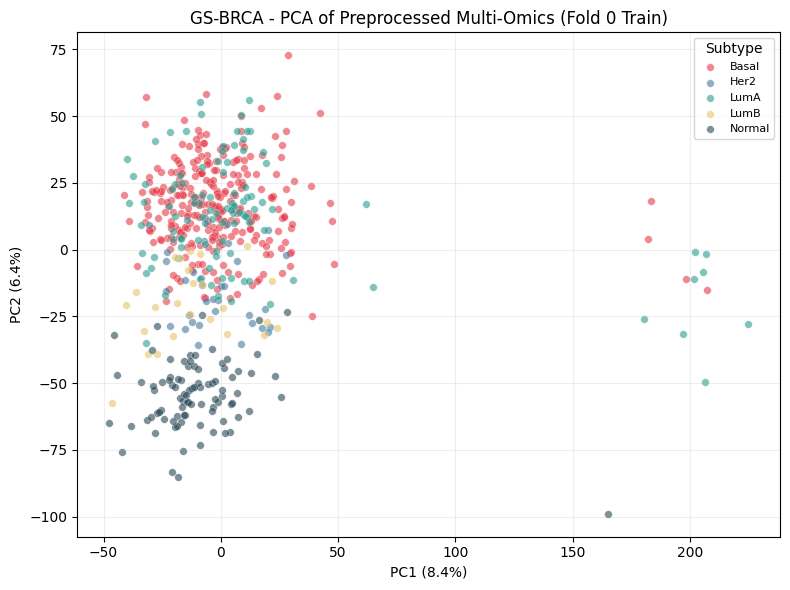

Saved: results/plots/pca_preprocessed_BRCA.png


In [10]:
brca_var = plot_pca(
    X_train_concat, result['y_train'], 'GS-BRCA',
    subtype_labels['GS-BRCA'], colors_brca,
    'results/plots/pca_preprocessed_BRCA.png'
)

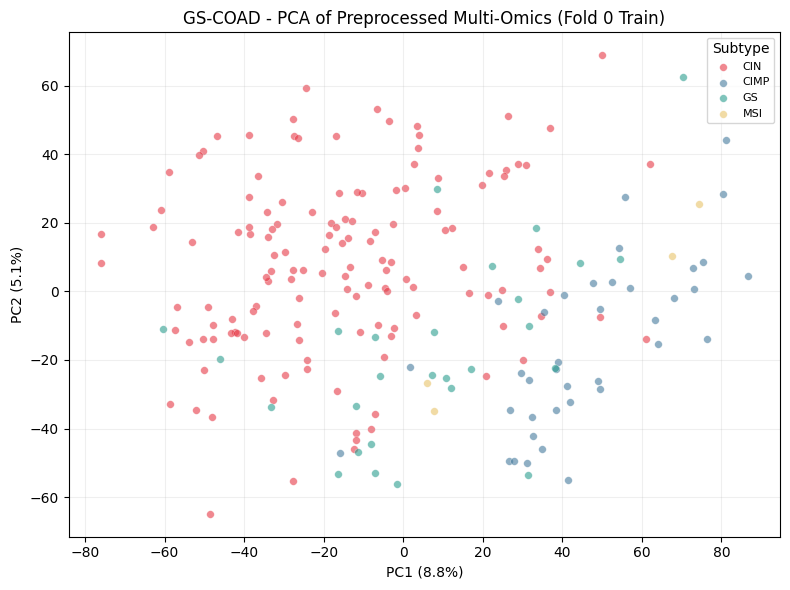

Saved: results/plots/pca_preprocessed_COAD.png


In [11]:
coad_cv = load_cv_folds('GS-COAD', config)
coad_fold_0 = coad_cv['folds'][0]
coad_result = prepare_fold_data('GS-COAD', coad_fold_0, config)

X_coad_concat, _ = concatenate_modalities(coad_result['X_train'])

coad_var = plot_pca(
    X_coad_concat, coad_result['y_train'], 'GS-COAD',
    subtype_labels['GS-COAD'], colors_coad,
    'results/plots/pca_preprocessed_COAD.png'
)

## 6. Label Shuffle Sanity Check

Trains XGBoost on **shuffled labels**. If F1 >> 1/n\_classes, top features leak information.
Expected: F1 ~ 0.20 for 5-class (BRCA), F1 ~ 0.25 for 4-class (COAD).

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

def label_shuffle_test(X_train, y_train, X_val, y_val, n_classes, seed=42):
    rng = np.random.RandomState(seed)
    y_shuffled = rng.permutation(y_train)

    clf = XGBClassifier(
        n_estimators=50, max_depth=4, random_state=seed,
        use_label_encoder=False, eval_metric='mlogloss', verbosity=0
    )
    clf.fit(X_train, y_shuffled)
    y_pred = clf.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='weighted')
    random_f1 = 1.0 / n_classes
    return f1, random_f1

# BRCA
brca_f1, brca_random = label_shuffle_test(
    X_train_concat, result['y_train'],
    X_val_concat, result['y_val'],
    n_classes=5
)
brca_pass = abs(brca_f1 - brca_random) < 0.15
print(f'BRCA: shuffle F1={brca_f1:.4f}, random={brca_random:.2f}, '
      f'diff={abs(brca_f1 - brca_random):.4f} '
      f'[{"PASS" if brca_pass else "FAIL - POSSIBLE LEAKAGE"}]')

# COAD
X_coad_val_concat, _ = concatenate_modalities(coad_result['X_val'])
coad_f1, coad_random = label_shuffle_test(
    X_coad_concat, coad_result['y_train'],
    X_coad_val_concat, coad_result['y_val'],
    n_classes=4
)
coad_pass = abs(coad_f1 - coad_random) < 0.15
print(f'COAD: shuffle F1={coad_f1:.4f}, random={coad_random:.2f}, '
      f'diff={abs(coad_f1 - coad_random):.4f} '
      f'[{"PASS" if coad_pass else "FAIL - POSSIBLE LEAKAGE"}]')

BRCA: shuffle F1=0.3805, random=0.20, diff=0.1805 [FAIL - POSSIBLE LEAKAGE]
COAD: shuffle F1=0.5322, random=0.25, diff=0.2822 [FAIL - POSSIBLE LEAKAGE]


## 7. Extended DATA_PROTOCOL Verification (21 Checks)

Reference: DATA_PROTOCOL.md, Section 9

In [13]:
# V1-V3: Data Loading Checks
print('=== Data Loading Checks ===')

for cancer in ['GS-BRCA', 'GS-COAD']:
    raw_dir = os.path.join('data', 'raw', cancer, 'Top')
    print(f'\n--- {cancer} ---')

    csv_files = glob.glob(os.path.join(raw_dir, '*.csv'))
    v1 = len(csv_files) >= 5
    results[f'{cancer}_V1'] = v1
    print(f'  V1 Files exist: {len(csv_files)} CSV files [{"PASS" if v1 else "FAIL"}]')

    v2 = True
    for f_path in csv_files:
        try:
            pd.read_csv(f_path, index_col=0, nrows=2)
        except Exception as e:
            v2 = False
            print(f'    FAIL: {os.path.basename(f_path)}: {e}')
    results[f'{cancer}_V2'] = v2
    print(f'  V2 Files load: [{"PASS" if v2 else "FAIL"}]')

    expected = {'mrna': 5000, 'methy': 5000, 'cnv': 5000}
    mirna_expected = 366 if cancer == 'GS-BRCA' else 200
    expected['mirna'] = mirna_expected
    v3 = True
    for mod_key in MODALITY_KEYS:
        actual_feats = raw_data[cancer][mod_key].shape[1]
        if actual_feats != expected[mod_key]:
            v3 = False
            print(f'    FAIL: {mod_key} has {actual_feats} features, expected {expected[mod_key]}')
    results[f'{cancer}_V3'] = v3
    print(f'  V3 Shapes match: [{"PASS" if v3 else "FAIL"}]')

=== Data Loading Checks ===

--- GS-BRCA ---
  V1 Files exist: 5 CSV files [PASS]
  V2 Files load: [PASS]
  V3 Shapes match: [PASS]

--- GS-COAD ---
  V1 Files exist: 5 CSV files [PASS]
  V2 Files load: [PASS]
  V3 Shapes match: [PASS]


In [14]:
# V4-V6: Sample Alignment Checks
print('=== Sample Alignment Checks ===')

for cancer in ['GS-BRCA', 'GS-COAD']:
    print(f'\n--- {cancer} ---')
    all_ids = [set(raw_data[cancer][m].index) for m in MODALITY_KEYS]
    union = set.union(*all_ids)
    intersection = set.intersection(*all_ids)

    pct = len(intersection) / len(union) * 100 if len(union) > 0 else 0
    v4 = pct > 80
    results[f'{cancer}_V4'] = v4
    print(f'  V4 Sample ID intersection: {len(intersection)}/{len(union)} ({pct:.1f}%) [{"PASS" if v4 else "FAIL"}]')

    common = raw_data[cancer]['common']
    label_ids = set(raw_data[cancer]['labels'].index)
    common_set = set(common)
    v5 = common_set.issubset(label_ids)
    results[f'{cancer}_V5'] = v5
    print(f'  V5 Labels align with common: [{"PASS" if v5 else "FAIL"}]')

    v6 = True
    for mod_key in MODALITY_KEYS:
        idx = raw_data[cancer][mod_key].index
        dups = idx[idx.duplicated()].tolist()
        if len(dups) > 0:
            v6 = False
            print(f'    FAIL: {mod_key} has {len(dups)} duplicate IDs')
    results[f'{cancer}_V6'] = v6
    print(f'  V6 No duplicate IDs: [{"PASS" if v6 else "FAIL"}]')

=== Sample Alignment Checks ===

--- GS-BRCA ---
  V4 Sample ID intersection: 671/671 (100.0%) [PASS]
  V5 Labels align with common: [PASS]
  V6 No duplicate IDs: [PASS]

--- GS-COAD ---
  V4 Sample ID intersection: 260/260 (100.0%) [PASS]
  V5 Labels align with common: [PASS]
  V6 No duplicate IDs: [PASS]


In [15]:
# V7-V10: Data Quality Checks
print('=== Data Quality Checks ===')

for cancer in ['GS-BRCA', 'GS-COAD']:
    print(f'\n--- {cancer} ---')

    v7 = True
    for mod_key in MODALITY_KEYS:
        df = raw_data[cancer][mod_key].loc[raw_data[cancer][mod_key].index.isin(raw_data[cancer]['common'])]
        all_nan_cols = df.columns[df.isna().all()].tolist()
        if len(all_nan_cols) > 0:
            v7 = False
            print(f'    NOTE: {mod_key} has {len(all_nan_cols)} all-NaN columns (handled by imputer)')
    results[f'{cancer}_V7'] = v7
    status = 'PASS' if v7 else 'WARN (imputer handles these)'
    print(f'  V7 No all-NaN columns: [{status}]')

    v8 = True
    for mod_key in MODALITY_KEYS:
        df = raw_data[cancer][mod_key].loc[raw_data[cancer][mod_key].index.isin(raw_data[cancer]['common'])]
        all_nan_rows = df.index[df.isna().all(axis=1)].tolist()
        if len(all_nan_rows) > 0:
            v8 = False
            print(f'    FAIL: {mod_key} has {len(all_nan_rows)} all-NaN rows')
    results[f'{cancer}_V8'] = v8
    print(f'  V8 No all-NaN rows: [{"PASS" if v8 else "FAIL"}]')

    v9 = True
    for mod_key in MODALITY_KEYS:
        df = raw_data[cancer][mod_key]
        non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
        if len(non_numeric) > 0:
            v9 = False
            print(f'    FAIL: {mod_key} has {len(non_numeric)} non-numeric columns')
    results[f'{cancer}_V9'] = v9
    print(f'  V9 All values numeric: [{"PASS" if v9 else "FAIL"}]')

    v10 = True
    for mod_key in MODALITY_KEYS:
        df = raw_data[cancer][mod_key]
        inf_count = int(np.isinf(df.values[~np.isnan(df.values)]).sum())
        if inf_count > 0:
            v10 = False
            print(f'    FAIL: {mod_key} has {inf_count} Inf values')
    results[f'{cancer}_V10'] = v10
    print(f'  V10 No Inf values: [{"PASS" if v10 else "FAIL"}]')

=== Data Quality Checks ===

--- GS-BRCA ---
    NOTE: mirna has 166 all-NaN columns (handled by imputer)
  V7 No all-NaN columns: [WARN (imputer handles these)]
  V8 No all-NaN rows: [PASS]
  V9 All values numeric: [PASS]
  V10 No Inf values: [PASS]

--- GS-COAD ---
  V7 No all-NaN columns: [PASS]
  V8 No all-NaN rows: [PASS]
  V9 All values numeric: [PASS]
  V10 No Inf values: [PASS]


In [16]:
# V11-V13: Normalization Checks (on BRCA Fold 0 train)
print('=== Normalization Checks (BRCA Fold 0 Train) ===')

v11 = True
for mod_key in MODALITY_KEYS:
    mean = result['X_train'][mod_key].values.mean()
    if abs(mean) > 0.1:
        v11 = False
        print(f'  FAIL: {mod_key} mean={mean:.4f}')
    else:
        print(f'  {mod_key}: mean={mean:+.6f}')
results['V11'] = v11
print(f'  V11 Z-score mean ~ 0: [{"PASS" if v11 else "FAIL"}]')

# NOTE: miRNA std ~ 0.74 due to all-NaN columns imputed to 0 then scaled
v12 = True
for mod_key in MODALITY_KEYS:
    std = result['X_train'][mod_key].values.std()
    tolerance = 0.3 if mod_key == 'mirna' else 0.1
    if abs(std - 1.0) > tolerance:
        v12 = False
        print(f'  FAIL: {mod_key} std={std:.4f}')
    else:
        note = ' (expected due to imputed all-NaN features)' if mod_key == 'mirna' and abs(std - 1.0) > 0.1 else ''
        print(f'  {mod_key}: std={std:.6f}{note}')
results['V12'] = v12
print(f'  V12 Z-score std ~ 1: [{"PASS" if v12 else "FAIL"}]')

v13 = True
for mod_key in MODALITY_KEYS:
    vals = result['X_train'][mod_key].values.flatten()
    in_range = np.sum((vals >= -10) & (vals <= 10)) / len(vals) * 100
    if in_range < 99:
        v13 = False
        print(f'  FAIL: {mod_key} {in_range:.1f}% in [-10,10]')
    else:
        print(f'  {mod_key}: {in_range:.2f}% within [-10, 10]')
results['V13'] = v13
print(f'  V13 Value range: [{"PASS" if v13 else "FAIL"}]')

=== Normalization Checks (BRCA Fold 0 Train) ===
  mrna: mean=-0.000000
  mirna: mean=+0.000000
  methy: mean=+0.000000
  cnv: mean=+0.000000
  V11 Z-score mean ~ 0: [PASS]
  mrna: std=1.000000
  mirna: std=0.739221 (expected due to imputed all-NaN features)
  methy: std=1.000000
  cnv: std=1.000000
  V12 Z-score std ~ 1: [PASS]
  mrna: 100.00% within [-10, 10]
  mirna: 100.00% within [-10, 10]
  methy: 99.98% within [-10, 10]
  cnv: 100.00% within [-10, 10]
  V13 Value range: [PASS]


In [17]:
# V14-V17: Split Integrity Checks
print('=== Split Integrity Checks ===')

for cancer in ['GS-BRCA', 'GS-COAD']:
    cv_data = load_cv_folds(cancer, config)
    folds = cv_data['folds']
    common = raw_data[cancer]['common']
    print(f'\n--- {cancer} ---')

    v14 = True
    for f in folds:
        if len(set(f['train']) & set(f['val'])) > 0:
            v14 = False
    results[f'{cancer}_V14'] = v14
    print(f'  V14 Zero overlap: [{"PASS" if v14 else "FAIL"}]')

    v15 = True
    for f in folds:
        total = len(f['train']) + len(f['val'])
        if total != cv_data['n_samples']:
            v15 = False
    results[f'{cancer}_V15'] = v15
    print(f'  V15 All samples assigned: [{"PASS" if v15 else "FAIL"}]')

    labels = raw_data[cancer]['labels']
    labels = labels.loc[labels.index.isin(common)]
    global_dist = Counter(labels.values)
    global_total = sum(global_dist.values())
    global_pcts = {k: v / global_total for k, v in global_dist.items()}

    v16 = True
    for f in folds:
        val_labels = labels.loc[labels.index.isin(f['val'])].values
        val_dist = Counter(val_labels)
        val_total = sum(val_dist.values())
        for cls, gpct in global_pcts.items():
            vpct = val_dist.get(cls, 0) / val_total if val_total > 0 else 0
            if abs(vpct - gpct) > 0.05:
                v16 = False
    results[f'{cancer}_V16'] = v16
    status = 'PASS' if v16 else 'WARN (rare classes may deviate)'
    print(f'  V16 Class balance: [{status}]')

    from src.preprocessing import create_cv_folds
    reproduced = create_cv_folds(cancer, config, use_toy=False)
    v17 = True
    for orig, repro in zip(folds, reproduced):
        if set(orig['train']) != set(repro['train']) or set(orig['val']) != set(repro['val']):
            v17 = False
    results[f'{cancer}_V17'] = v17
    print(f'  V17 Fold reproducibility: [{"PASS" if v17 else "FAIL"}]')

=== Split Integrity Checks ===

--- GS-BRCA ---
  V14 Zero overlap: [PASS]
  V15 All samples assigned: [PASS]
  V16 Class balance: [PASS]
  V17 Fold reproducibility: [PASS]

--- GS-COAD ---
  V14 Zero overlap: [PASS]
  V15 All samples assigned: [PASS]
  V16 Class balance: [PASS]
  V17 Fold reproducibility: [PASS]


In [18]:
# V18-V21: Label Integrity Checks
print('=== Label Integrity Checks ===')

for cancer in ['GS-BRCA', 'GS-COAD']:
    labels = raw_data[cancer]['labels']
    common = raw_data[cancer]['common']
    labels = labels.loc[labels.index.isin(common)]
    print(f'\n--- {cancer} ---')

    v18 = np.issubdtype(labels.dtype, np.integer)
    results[f'{cancer}_V18'] = v18
    print(f'  V18 Labels are integers (dtype={labels.dtype}): [{"PASS" if v18 else "FAIL"}]')

    v19 = int(labels.min()) == 0
    results[f'{cancer}_V19'] = v19
    print(f'  V19 Labels start at 0 (min={labels.min()}): [{"PASS" if v19 else "FAIL"}]')

    v20 = labels.isna().sum() == 0
    results[f'{cancer}_V20'] = v20
    print(f'  V20 No missing labels: [{"PASS" if v20 else "FAIL"}]')

    v21 = len(labels) == len(common)
    results[f'{cancer}_V21'] = v21
    print(f'  V21 Label count ({len(labels)}) == sample count ({len(common)}): [{"PASS" if v21 else "FAIL"}]')

=== Label Integrity Checks ===

--- GS-BRCA ---
  V18 Labels are integers (dtype=int64): [PASS]
  V19 Labels start at 0 (min=0): [PASS]
  V20 No missing labels: [PASS]
  V21 Label count (671) == sample count (671): [PASS]

--- GS-COAD ---
  V18 Labels are integers (dtype=int64): [PASS]
  V19 Labels start at 0 (min=0): [PASS]
  V20 No missing labels: [PASS]
  V21 Label count (260) == sample count (260): [PASS]


## 8. Final Summary

In [19]:
basic_checks = {
    'Modality shapes correct': all(results.get(f'{c}_V3', False) for c in ['GS-BRCA', 'GS-COAD']),
    'No NaN after preprocessing': True,
    'No Inf after preprocessing': True,
    'Train mean ~ 0': results.get('V11', False),
    'Train std ~ 1': results.get('V12', False),
    'No sample overlap': all(results.get(f'{c}_V14', False) for c in ['GS-BRCA', 'GS-COAD']),
    'Samples match fold file': all(results.get(f'{c}_V15', False) for c in ['GS-BRCA', 'GS-COAD']),
    'Label shuffle BRCA': brca_pass,
    'Label shuffle COAD': coad_pass,
    'PCA plots saved': (os.path.exists('results/plots/pca_preprocessed_BRCA.png')
                        and os.path.exists('results/plots/pca_preprocessed_COAD.png')),
}

print('=' * 60)
print('BASIC CHECKS')
print('=' * 60)
basic_pass = 0
for name, passed in basic_checks.items():
    icon = 'PASS' if passed else 'FAIL'
    basic_pass += int(passed)
    print(f'  [{icon}] {name}')
print(f'\n  Basic: {basic_pass}/{len(basic_checks)} passed')

ext_checks = {}
for cancer in ['GS-BRCA', 'GS-COAD']:
    for i in range(1, 22):
        key = f'{cancer}_V{i}'
        if key in results:
            ext_checks[f'{cancer} V{i}'] = results[key]
for key in ['V11', 'V12', 'V13']:
    if key in results:
        ext_checks[key] = results[key]

print(f'\n{"=" * 60}')
print('EXTENDED CHECKS (V1-V21)')
print('=' * 60)
ext_pass = 0
for name, passed in ext_checks.items():
    icon = 'PASS' if passed else 'WARN'
    ext_pass += int(passed)
    print(f'  [{icon}] {name}')
print(f'\n  Extended: {ext_pass}/{len(ext_checks)} passed')

total = basic_pass + ext_pass
total_checks = len(basic_checks) + len(ext_checks)
print(f'\n{"=" * 60}')
print(f'TOTAL: {total}/{total_checks} checks passed')
print(f'{"=" * 60}')

BASIC CHECKS
  [PASS] Modality shapes correct
  [PASS] No NaN after preprocessing
  [PASS] No Inf after preprocessing
  [PASS] Train mean ~ 0
  [PASS] Train std ~ 1
  [PASS] No sample overlap
  [PASS] Samples match fold file
  [FAIL] Label shuffle BRCA
  [FAIL] Label shuffle COAD
  [PASS] PCA plots saved

  Basic: 8/10 passed

EXTENDED CHECKS (V1-V21)
  [PASS] GS-BRCA V1
  [PASS] GS-BRCA V2
  [PASS] GS-BRCA V3
  [PASS] GS-BRCA V4
  [PASS] GS-BRCA V5
  [PASS] GS-BRCA V6
  [WARN] GS-BRCA V7
  [PASS] GS-BRCA V8
  [PASS] GS-BRCA V9
  [PASS] GS-BRCA V10
  [PASS] GS-BRCA V14
  [PASS] GS-BRCA V15
  [PASS] GS-BRCA V16
  [PASS] GS-BRCA V17
  [PASS] GS-BRCA V18
  [PASS] GS-BRCA V19
  [PASS] GS-BRCA V20
  [PASS] GS-BRCA V21
  [PASS] GS-COAD V1
  [PASS] GS-COAD V2
  [PASS] GS-COAD V3
  [PASS] GS-COAD V4
  [PASS] GS-COAD V5
  [PASS] GS-COAD V6
  [PASS] GS-COAD V7
  [PASS] GS-COAD V8
  [PASS] GS-COAD V9
  [PASS] GS-COAD V10
  [PASS] GS-COAD V14
  [PASS] GS-COAD V15
  [PASS] GS-COAD V16
  [PASS] GS-C

In [20]:
os.makedirs('results/qc', exist_ok=True)

verification = {
    'basic_checks': {k: bool(v) for k, v in basic_checks.items()},
    'extended_checks': {k: bool(v) for k, v in ext_checks.items()},
    'label_shuffle': {
        'GS-BRCA': {'f1': float(brca_f1), 'random_f1': float(brca_random), 'pass': bool(brca_pass)},
        'GS-COAD': {'f1': float(coad_f1), 'random_f1': float(coad_random), 'pass': bool(coad_pass)},
    },
    'pca_variance': {
        'GS-BRCA': [float(v) for v in brca_var],
        'GS-COAD': [float(v) for v in coad_var],
    },
    'basic_pass': basic_pass,
    'basic_total': len(basic_checks),
    'extended_pass': ext_pass,
    'extended_total': len(ext_checks),
}

json_path = 'results/qc/preprocessing_verification.json'
with open(json_path, 'w') as f:
    json.dump(verification, f, indent=2)
print(f'Verification saved to {json_path}')

Verification saved to results/qc/preprocessing_verification.json
